In [30]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

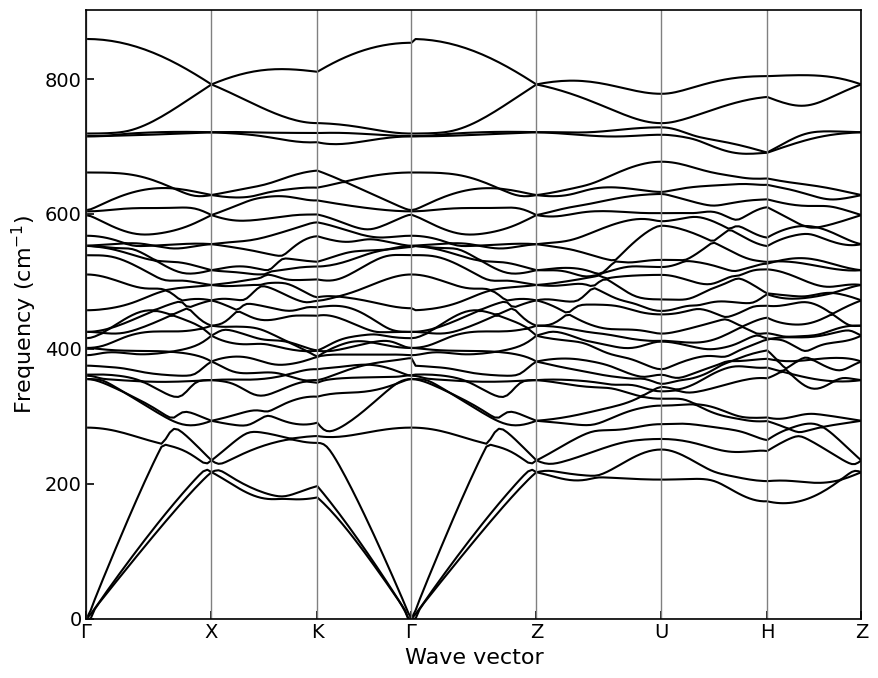

In [32]:
freq_file = Path("Al2O3.freq.gp")
data = np.loadtxt(freq_file)
x = data[:, 0]
freqs = data[:, 1:]
freqs_plot = freqs.copy()
freqs_plot[freqs_plot < 0] = 0.0
nbnd = freqs_plot.shape[1]
# print("Parsed q-points:", len(x))
# print("Parsed modes:", nbnd)
# print("Minimum original frequency:", freqs.min(), "cm^-1")
# print("Minimum plotted frequency:", freqs_plot.min(), "cm^-1")
# print("Number of negative values moved to zero:", np.sum(freqs < 0))

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.linewidth": 1.2,
})

fig, ax = plt.subplots(figsize=(9, 7))

for mode in range(nbnd):
    ax.plot(x, freqs_plot[:, mode], color="black", linewidth=1.5)

labels = [r"$\Gamma$", "X", "K", r"$\Gamma$", "Z", "U", "H", "Z"]

tick_indices = [0, 30, 60, 90, 120, 150, 180, len(x) - 1]
tick_indices = [i for i in tick_indices if i < len(x)]
tick_positions = [x[i] for i in tick_indices]

for xpos in tick_positions:
    ax.axvline(x=xpos, color="gray", linewidth=1.0)

ax.axhline(y=0, color="gray", linewidth=1.0)

ax.set_xticks(tick_positions)
ax.set_xticklabels(labels[:len(tick_positions)])

ax.set_ylabel(r"Frequency (cm$^{-1}$)")
ax.set_xlabel("Wave vector")

ax.set_xlim(x[0], x[-1])
ax.set_ylim(bottom=0)

ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
ax.tick_params(direction="in", length=6, width=1.2)

plt.tight_layout()
plt.savefig("Al2O3_black_phonon_dispersion.png", dpi=300, bbox_inches="tight")
plt.show()